Loaded: SVRG_MNIST_one_layer_Temperature50  (300 epochs)
Loaded: SVRG_MNIST_one_layer_Temperature50  (300 epochs)
Loaded: SVRG_MNIST_one_layer_Temperature50  (300 epochs)
Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


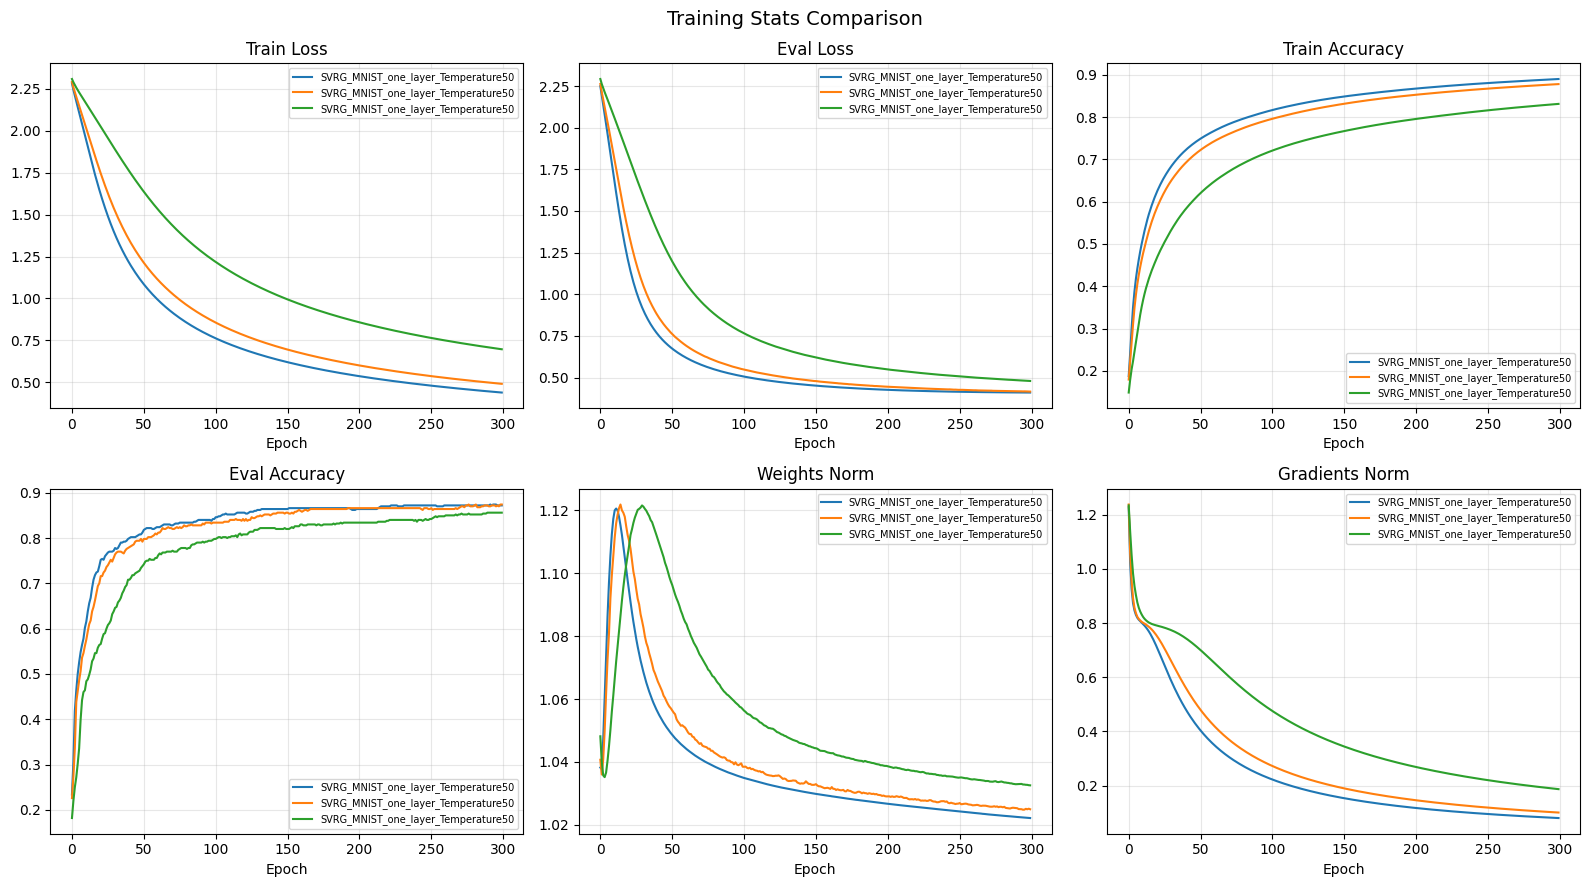

Saved: ./q1/mnist/train_loss.pdf
Saved: ./q1/mnist/eval_loss.pdf
Saved: ./q1/mnist/train_acc.pdf
Saved: ./q1/mnist/eval_acc.pdf
Saved: ./q1/mnist/weights.pdf
Saved: ./q1/mnist/grads.pdf


In [37]:

#Q1, different batchsize
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-085525_SVRG_MNIST_one_layer_Temperature50_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-193800_SVRG_MNIST_one_layer_Temperature50_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-095350_SVRG_MNIST_one_layer_Temperature50_lr0.003_seed2025", 
]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
pdf_dir   = './q1/mnist/'
os.makedirs(pdf_dir, exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SPRINT (batchsize=64)',
    'SPRINT (batchsize=128)',
    'SPRINT (batchsize=256)',
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


Loaded: SVRG_MNIST_one_layer_Temperature80.0  (300 epochs)
Loaded: SVRG_MNIST_one_layer_Temperature150  (300 epochs)
Loaded: SVRG_MNIST_one_layer_Temperature200  (300 epochs)
Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


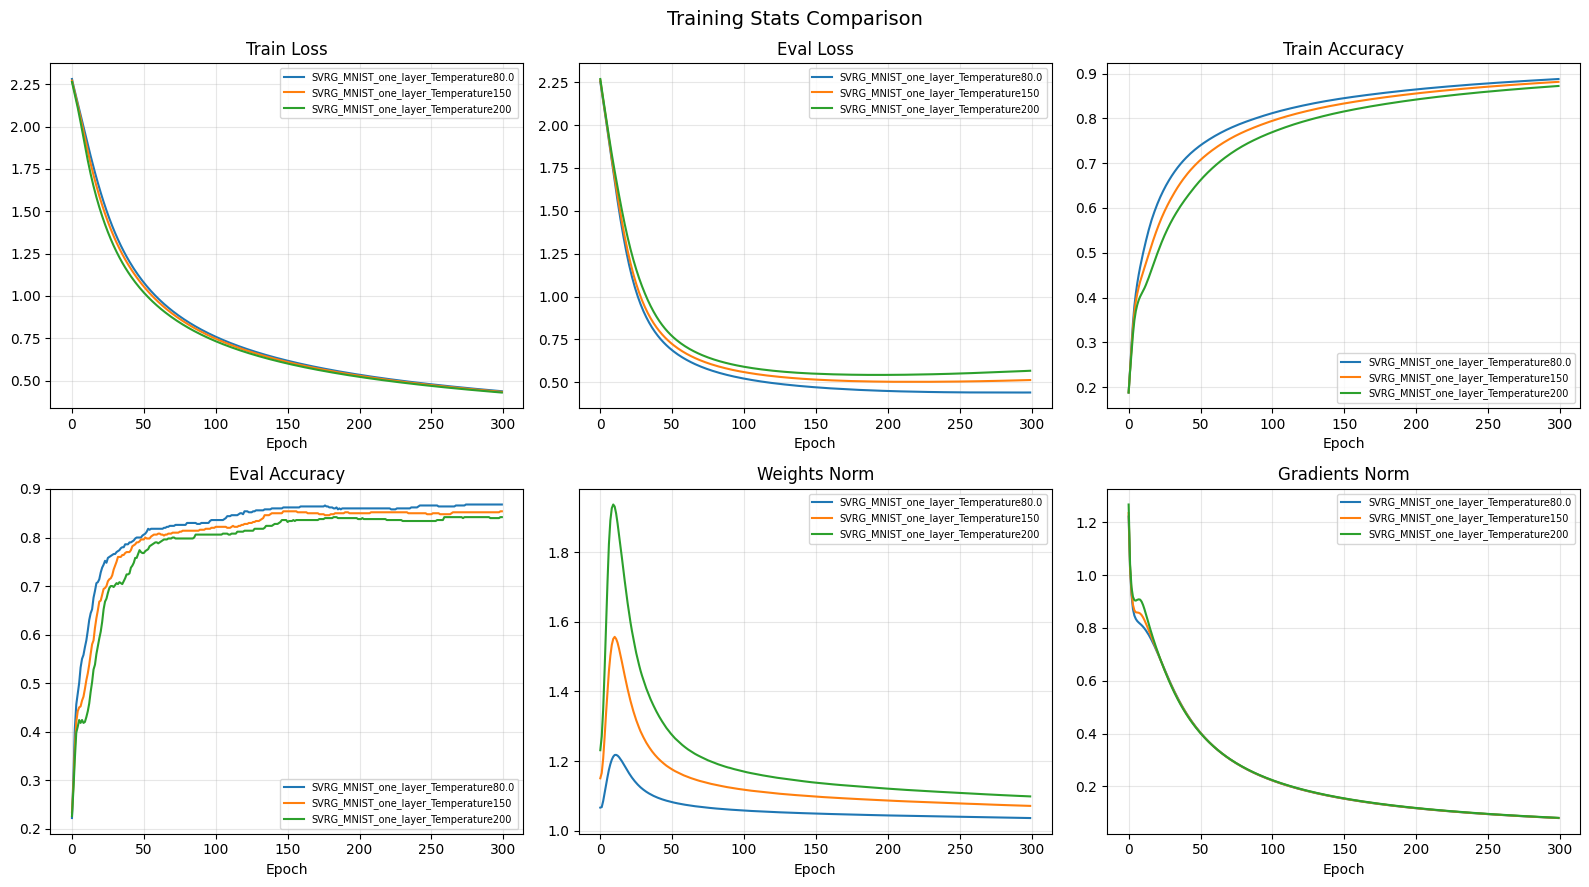

Saved: ./q2/mnist/train_loss.pdf
Saved: ./q2/mnist/eval_loss.pdf
Saved: ./q2/mnist/train_acc.pdf
Saved: ./q2/mnist/eval_acc.pdf
Saved: ./q2/mnist/weights.pdf
Saved: ./q2/mnist/grads.pdf


In [30]:
#Q2, large alpha
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    # '/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-083521_SVRG_CIFAR10_CIFAR10_convnet_Temperature20.0_lr0.05_seed2025',
    # '/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-083030_SGD_CIFAR10_CIFAR10_convnet_Temperature20.0_lr0.05_seed2025',
    # 继续添加更多路径 ...
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-090421_SVRG_MNIST_one_layer_Temperature50.0_lr0.003_seed2025"
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-222708_SGD_MNIST_one_layer_Temperature50.0_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-224558_SVRG_MNIST_one_layer_Temperature20.0_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-220714_SVRG_MNIST_one_layer_Temperature50.0_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-215649_SGD_MNIST_one_layer_Temperature80.0_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-215528_SVRG_MNIST_one_layer_Temperature80.0_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-084150_SVRG_MNIST_one_layer_Temperature150_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-233620_SVRG_MNIST_one_layer_Temperature200_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-220714_SVRG_MNIST_one_layer_Temperature50.0_lr0.003_seed2025",    
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-085525_SVRG_MNIST_one_layer_Temperature50_lr0.003_seed2025",
]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()





# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
metric_col = 'eval_loss'   # 可选: train_loss, eval_loss, train_acc, eval_acc, weights, grads
pdf_dir   = './q2/mnist/'
os.makedirs(os.path.dirname(pdf_path), exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SPRINT (alpha=80)',
    'SPRINT (alpha=150)',
    'SPRINT (alpha=200)',
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


Loaded: SVRG_MNIST_one_layer_Temperature50  (300 epochs)
Loaded: SVRG_MNIST_one_layer_Temperature50.0  (300 epochs)
Loaded: SGD_MNIST_one_layer_Temperature50  (300 epochs)
Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


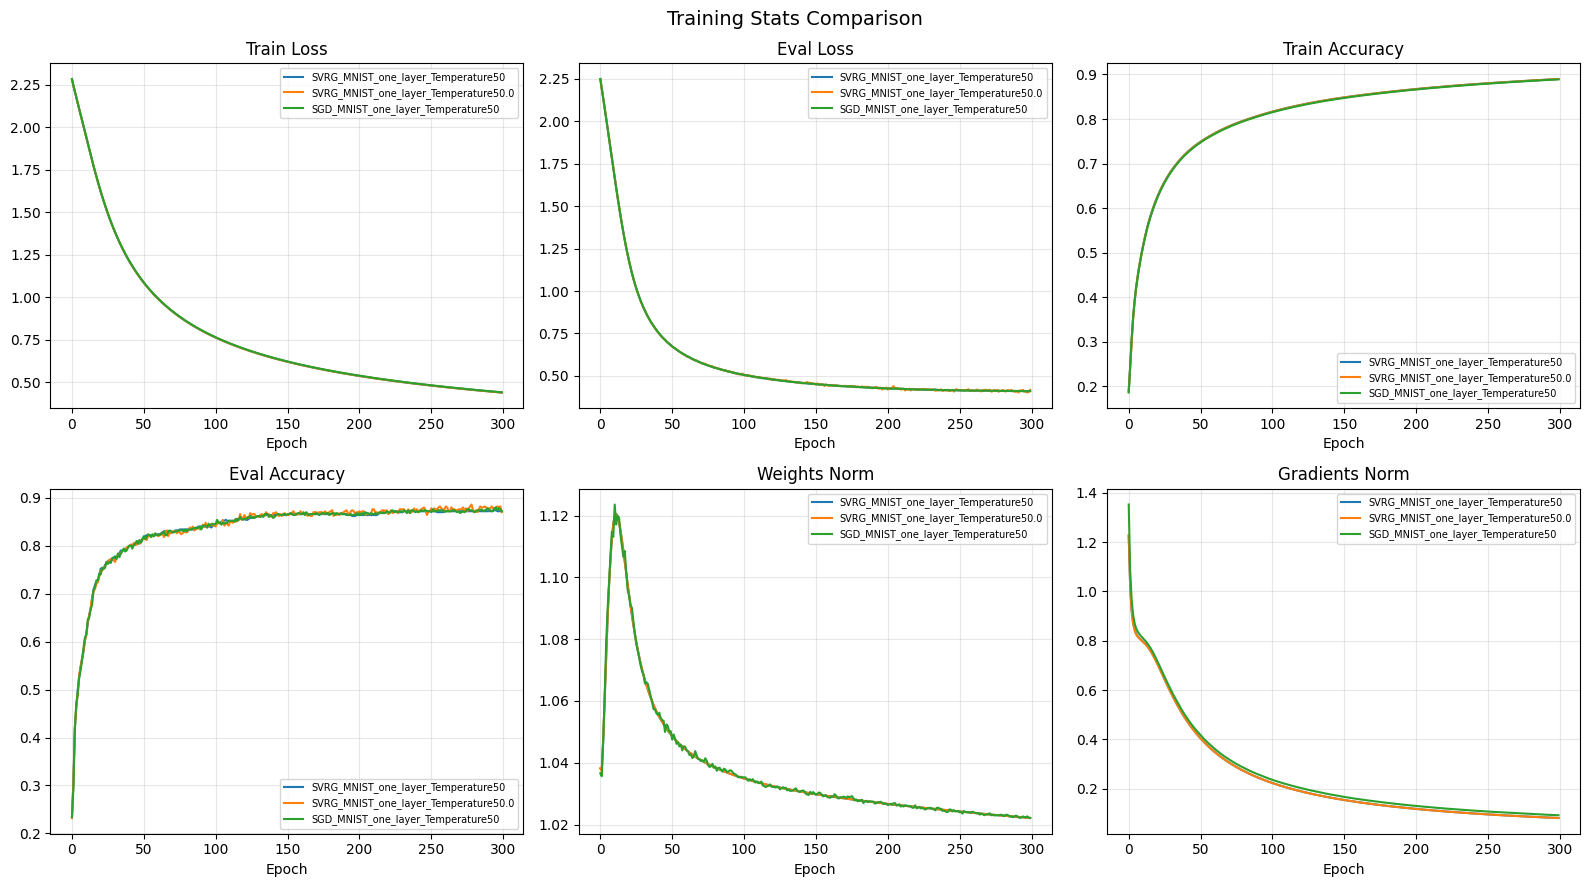

Saved: ./q3/mnist/train_loss.pdf
Saved: ./q3/mnist/eval_loss.pdf
Saved: ./q3/mnist/train_acc.pdf
Saved: ./q3/mnist/eval_acc.pdf
Saved: ./q3/mnist/weights.pdf
Saved: ./q3/mnist/grads.pdf


In [36]:

#Q3, partial grad
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    # '/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-083521_SVRG_CIFAR10_CIFAR10_convnet_Temperature20.0_lr0.05_seed2025',
    # '/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-083030_SGD_CIFAR10_CIFAR10_convnet_Temperature20.0_lr0.05_seed2025',
    # 继续添加更多路径 ...
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-090421_SVRG_MNIST_one_layer_Temperature50.0_lr0.003_seed2025"
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-222708_SGD_MNIST_one_layer_Temperature50.0_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260325-224558_SVRG_MNIST_one_layer_Temperature20.0_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-220714_SVRG_MNIST_one_layer_Temperature50.0_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-215649_SGD_MNIST_one_layer_Temperature80.0_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-085525_SVRG_MNIST_one_layer_Temperature50_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-220714_SVRG_MNIST_one_layer_Temperature50.0_lr0.003_seed2025", 
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-193612_SGD_MNIST_one_layer_Temperature50_lr0.003_seed2025"
]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
metric_col = 'eval_loss'   # 可选: train_loss, eval_loss, train_acc, eval_acc, weights, grads
pdf_dir   = './q3/mnist/'
os.makedirs(pdf_dir, exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SPRINT (full gradient)',
    'SPRINT (n_samples=256)',
    'SPRINT (n_samples=512)',
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


Loaded: SVRG_MNIST_one_layer_Temperature80  (300 epochs)
Loaded: SGD_MNIST_one_layer_Temperature80  (300 epochs)
Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


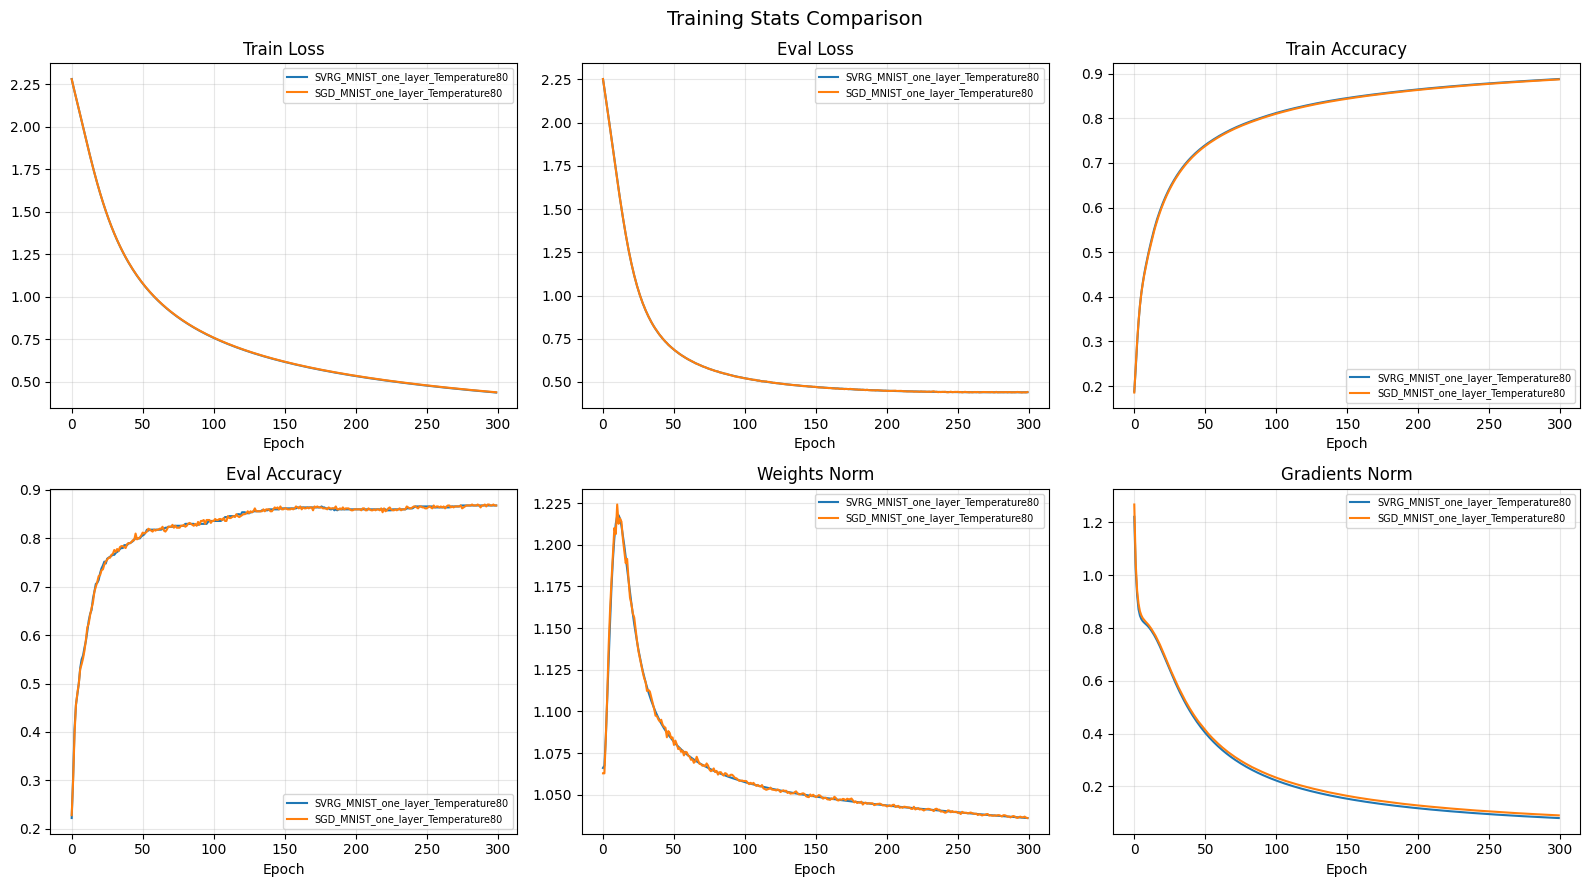

Saved: ./q4/mnist/train_loss.pdf
Saved: ./q4/mnist/eval_loss.pdf
Saved: ./q4/mnist/train_acc.pdf
Saved: ./q4/mnist/eval_acc.pdf
Saved: ./q4/mnist/weights.pdf
Saved: ./q4/mnist/grads.pdf


In [3]:

#Q4, eval sgd vs sprint
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-215243_SVRG_MNIST_one_layer_Temperature20_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-225506_SGD_MNIST_one_layer_Temperature20_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-215247_SVRG_MNIST_one_layer_Temperature50_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-225450_SGD_MNIST_one_layer_Temperature50_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-215303_SVRG_MNIST_one_layer_Temperature80_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-225431_SGD_MNIST_one_layer_Temperature80_lr0.003_seed2025"

]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
metric_col = 'eval_loss'   # 可选: train_loss, eval_loss, train_acc, eval_acc, weights, grads
pdf_dir   = './q4/mnist/'
os.makedirs(pdf_dir, exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SGD',
    'SPRINT',
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


Loaded: SVRG_credit_mlp_Temperature0.5_lr0.001  (300 epochs)
Loaded: SVRG_credit_mlp_Temperature0.5_lr0.001  (300 epochs)
Loaded: SVRG_credit_mlp_Temperature0.5_lr0.001  (300 epochs)


/local/scratch/ding/tmp/ipykernel_143925/567419951.py:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


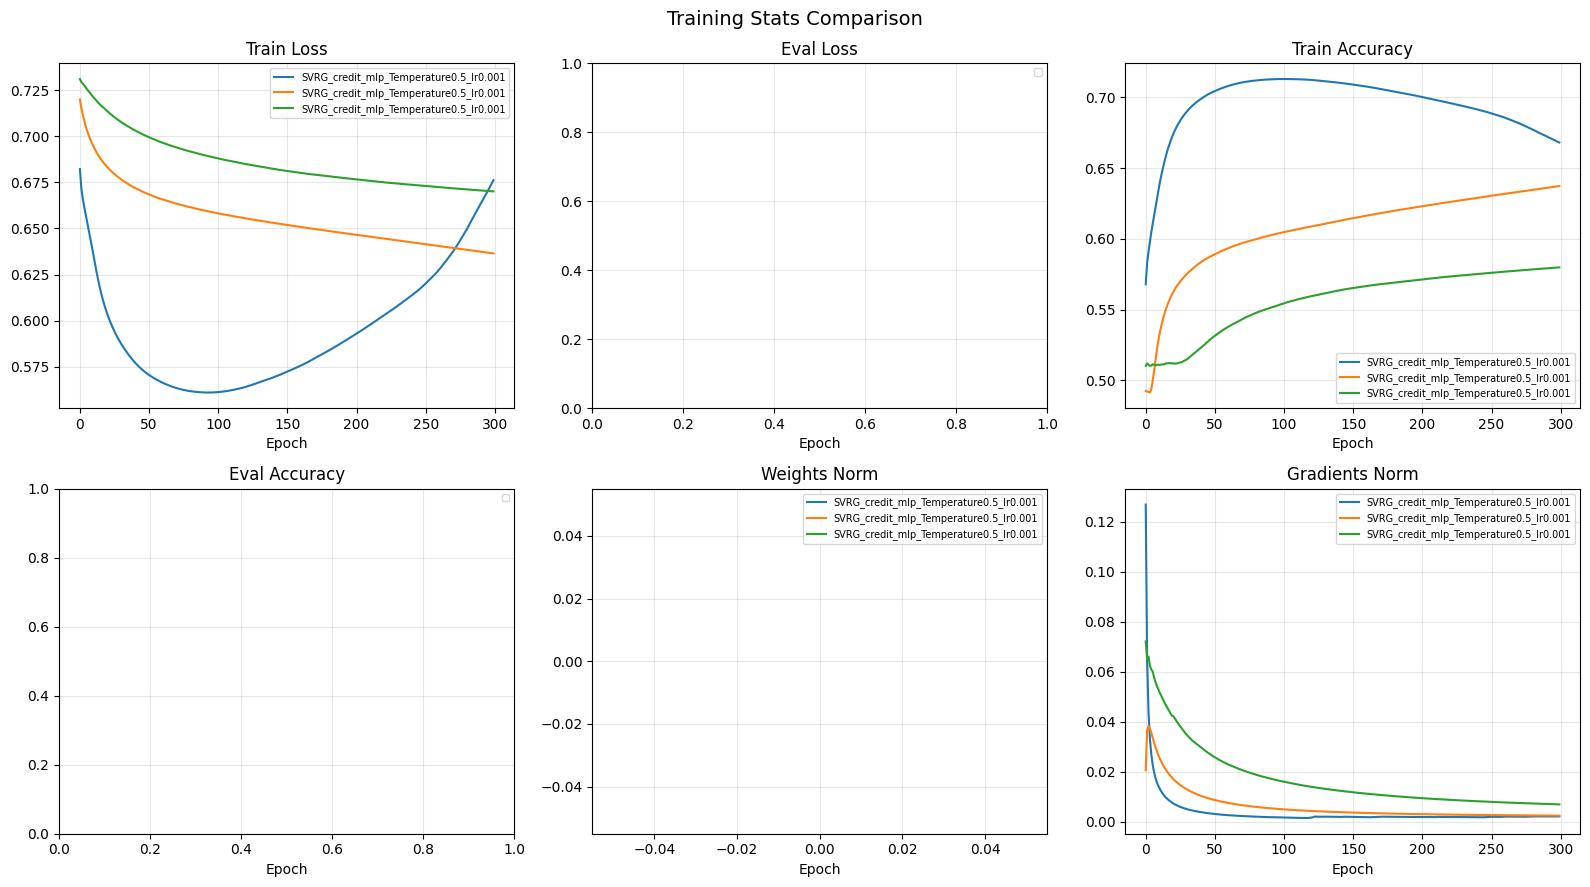

Saved: ./q1/credit/train_loss.pdf


/local/scratch/ding/tmp/ipykernel_143925/567419951.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


Saved: ./q1/credit/eval_loss.pdf
Saved: ./q1/credit/train_acc.pdf


/local/scratch/ding/tmp/ipykernel_143925/567419951.py:96: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=9)


Saved: ./q1/credit/eval_acc.pdf
Saved: ./q1/credit/weights.pdf
Saved: ./q1/credit/grads.pdf


In [2]:

#Q1, different batchsize
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-132848_SVRG_credit_mlp_Temperature0.5_lr0.001_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-132855_SVRG_credit_mlp_Temperature0.5_lr0.001_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-132859_SVRG_credit_mlp_Temperature0.5_lr0.001_seed2025",
]

custom_legends = [
    'SPRINT (batchsize=1)',
    'SPRINT (batchsize=32)',
    'SPRINT (batchsize=128)',
]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
metric_col = 'eval_loss'   # 可选: train_loss, eval_loss, train_acc, eval_acc, weights, grads
pdf_dir   = './q1/credit/'
os.makedirs(pdf_dir, exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SPRINT (batchsize=1)',
    'SPRINT (batchsize=32)',
    'SPRINT (batchsize=128)',
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


Loaded: SVRG_credit_mlp_Temperature0.5_lr0.001  (220 epochs)
Loaded: SVRG_credit_mlp_Temperature1.0_lr0.001  (72 epochs)
Loaded: SVRG_credit_mlp_Temperature2.0_lr0.001  (233 epochs)
Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


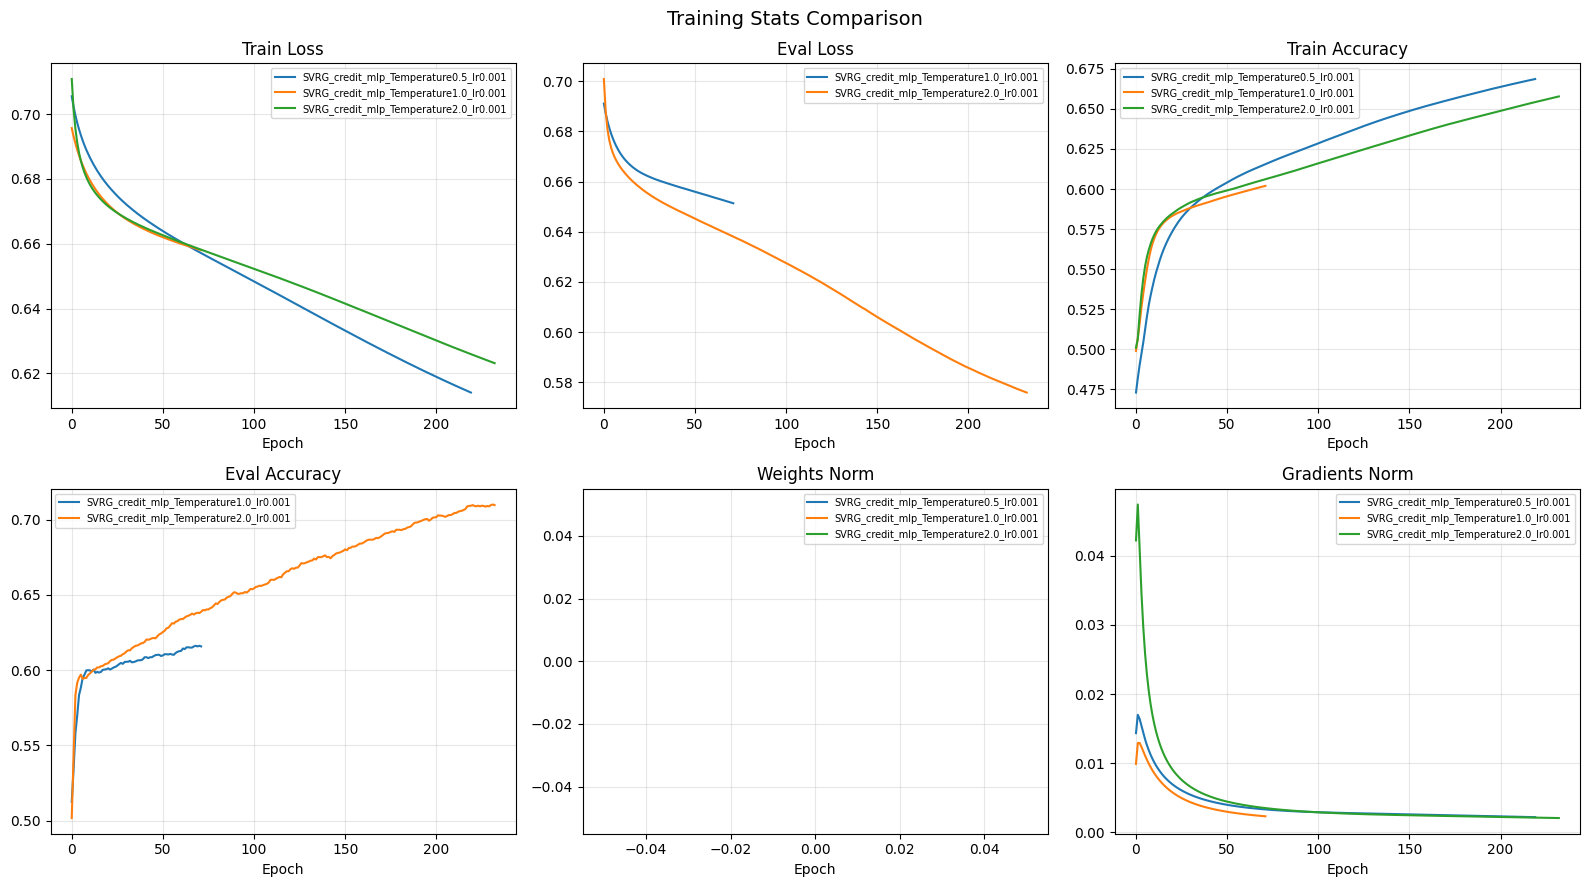

Saved: ./q2/credit/train_loss.pdf
Saved: ./q2/credit/eval_loss.pdf
Saved: ./q2/credit/train_acc.pdf
Saved: ./q2/credit/eval_acc.pdf
Saved: ./q2/credit/weights.pdf
Saved: ./q2/credit/grads.pdf


In [3]:

#Q2, large alpha
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260326-132900_SVRG_credit_mlp_Temperature0.5_lr0.001_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-101837_SVRG_credit_mlp_Temperature1.0_lr0.001_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-194451_SVRG_credit_mlp_Temperature2.0_lr0.001_seed2025"
]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
metric_col = 'eval_loss'   # 可选: train_loss, eval_loss, train_acc, eval_acc, weights, grads
pdf_dir   = './q2/credit/'
os.makedirs(pdf_dir, exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SPRINT (alpha=0.5)',
    'SPRINT (alpha=1.0)',
    'SPRINT (alpha=2.0)'
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


Loaded: SVRG_credit_mlp_Temperature1.0_lr0.001  (300 epochs)
Loaded: SVRG_credit_mlp_Temperature1.0_lr0.001  (72 epochs)
Loaded: SVRG_credit_mlp_Temperature1.0_lr0.001  (300 epochs)
Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


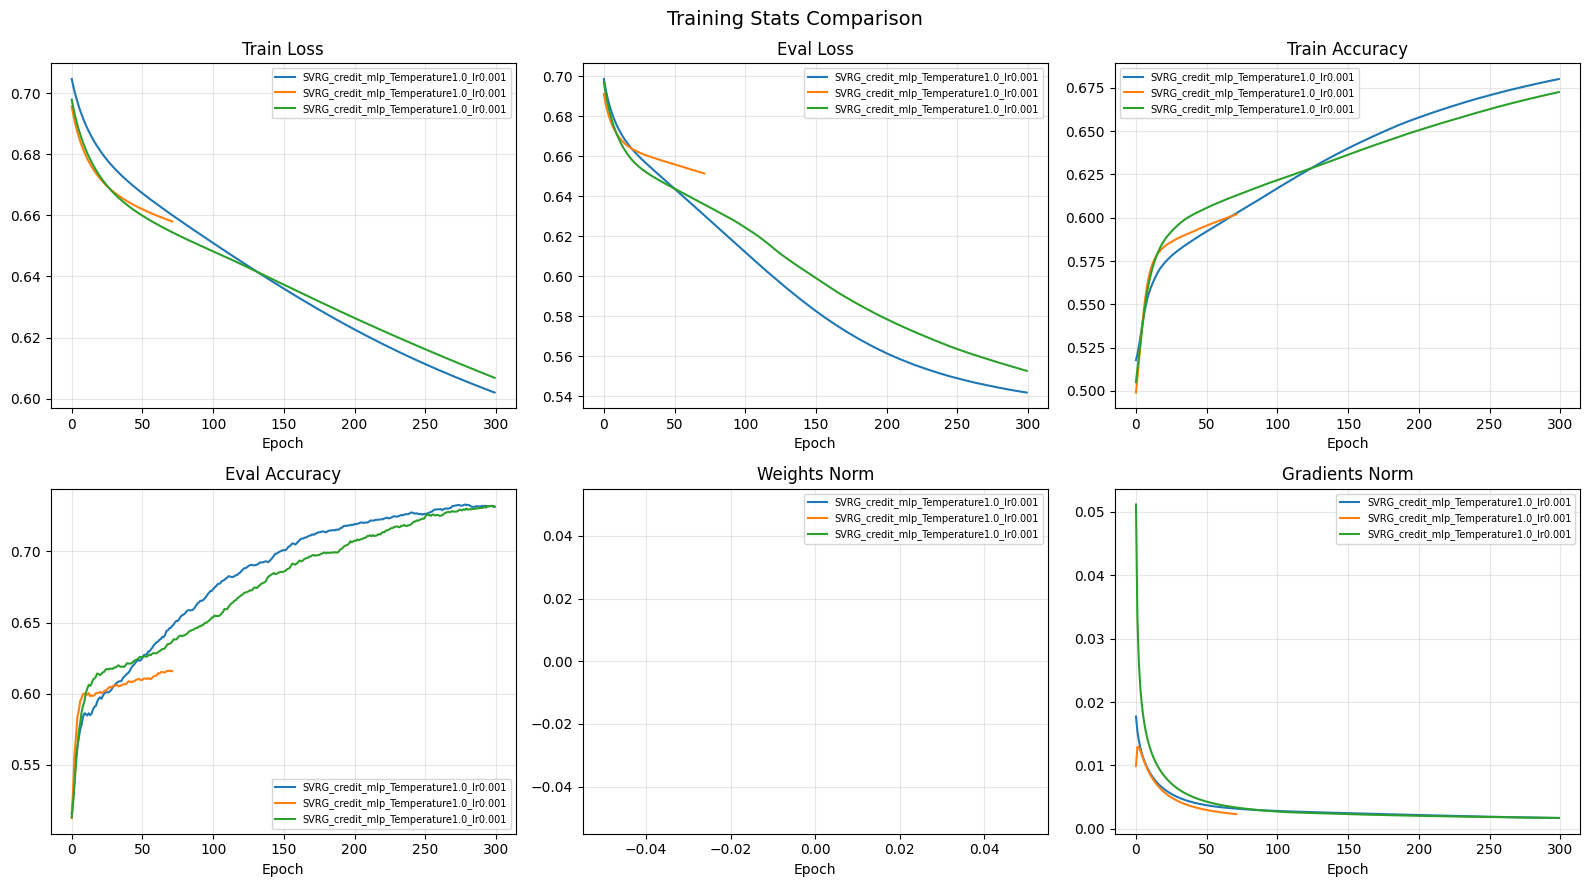

Saved: ./q3/credit/train_loss.pdf
Saved: ./q3/credit/eval_loss.pdf
Saved: ./q3/credit/train_acc.pdf
Saved: ./q3/credit/eval_acc.pdf
Saved: ./q3/credit/weights.pdf
Saved: ./q3/credit/grads.pdf


In [9]:

#Q3, partial grad
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-171905_SVRG_credit_mlp_Temperature1.0_lr0.001_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-101837_SVRG_credit_mlp_Temperature1.0_lr0.001_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-102302_SVRG_credit_mlp_Temperature1.0_lr0.001_seed2025"
]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
metric_col = 'eval_loss'   # 可选: train_loss, eval_loss, train_acc, eval_acc, weights, grads
pdf_dir   = './q3/credit/'
os.makedirs(pdf_dir, exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SPRINT (full gradient)',
    'SPRINT (n_samples=256)',
    'SPRINT (n_samples=512)',
    # 'SPRINT (alpha=200)',
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


Loaded: SVRG_credit_mlp_Temperature0.4_lr0.003  (181 epochs)
Loaded: SGD_credit_mlp_Temperature0.4_lr0.003  (178 epochs)
Saved to /home/zhu.3723/code/code/PP_SVRG/outputs/comparison_plot.png


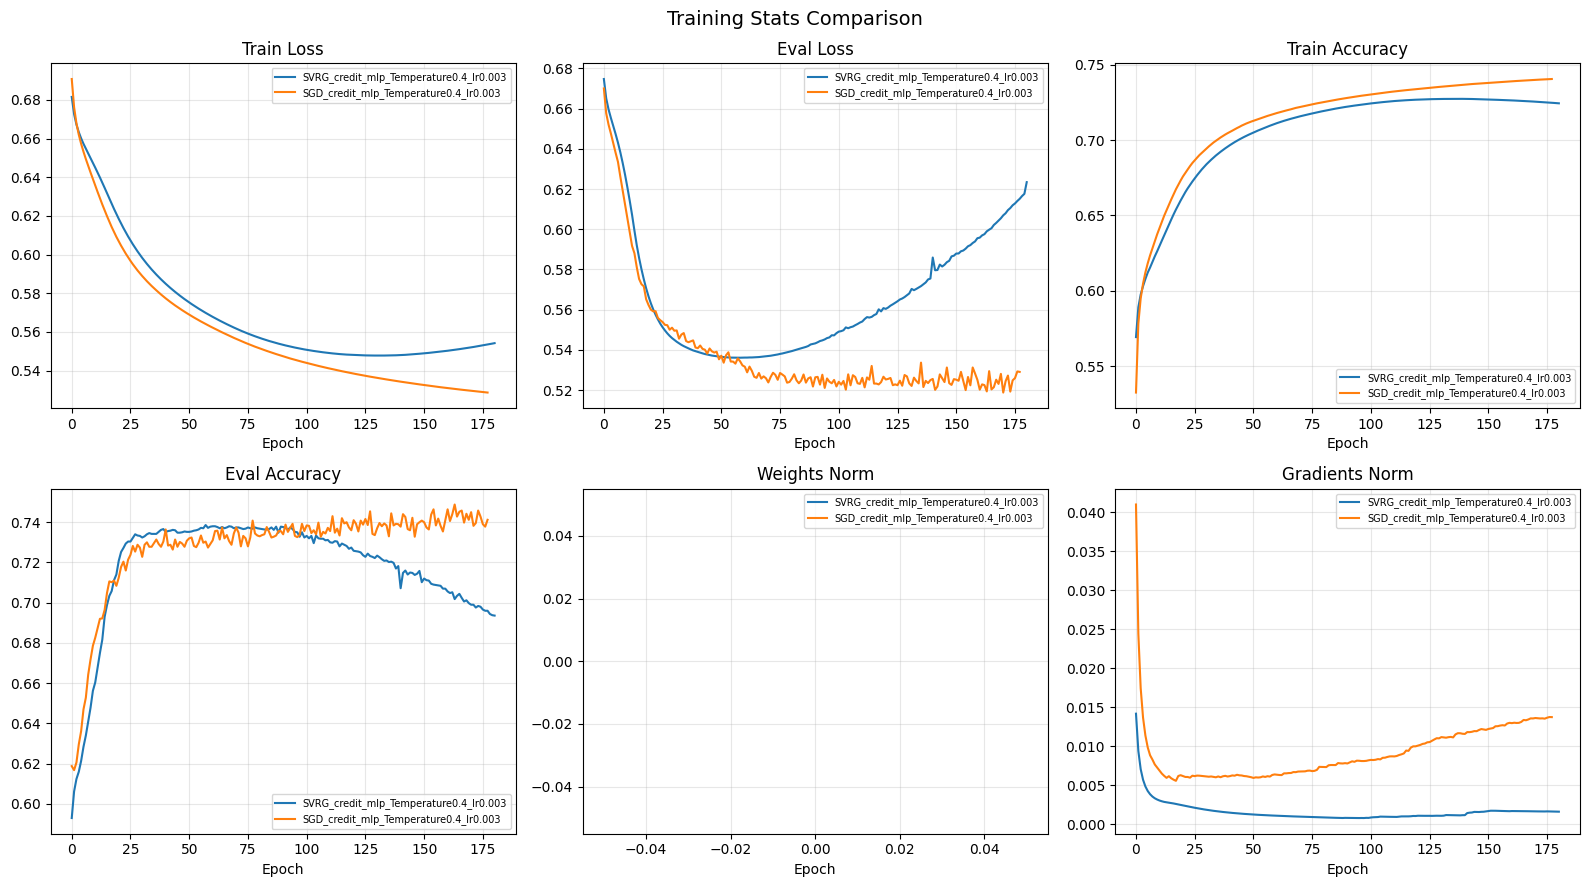

Saved: ./q3/credit/train_loss.pdf
Saved: ./q3/credit/eval_loss.pdf
Saved: ./q3/credit/train_acc.pdf
Saved: ./q3/credit/eval_acc.pdf
Saved: ./q3/credit/weights.pdf
Saved: ./q3/credit/grads.pdf


In [7]:

#Q4, eval sgd vs sprint
import pandas as pd
import matplotlib.pyplot as plt
import os

# ── 配置：添加/删除路径即可，label 会自动从文件夹名解析 ──────────────────
output_dirs = [
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-214350_SVRG_credit_mlp_Temperature0.01_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-225643_SGD_credit_mlp_Temperature0.01_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-214413_SVRG_credit_mlp_Temperature0.2_lr0.003_seed2025",
    # "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-225715_SGD_credit_mlp_Temperature0.2_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-214814_SVRG_credit_mlp_Temperature0.4_lr0.003_seed2025",
    "/home/zhu.3723/code/code/PP_SVRG/outputs/20260327-225808_SGD_credit_mlp_Temperature0.4_lr0.003_seed2025"
]

def parse_label(path):
    """从文件夹名生成简洁 label：时间戳_算法_数据集_..."""
    name = os.path.basename(path)
    parts = name.split('_')
    # 保留时间戳后的部分，最多取前5段避免太长
    return '_'.join(parts[1:6])

# 读取所有 CSV
runs = []
for d in output_dirs:
    csv_path = os.path.join(d, 'train_stats.csv')
    df = pd.read_csv(csv_path, index_col=0)
    label = parse_label(d)
    runs.append({'label': label, 'df': df, 'dir': d})
    print(f"Loaded: {label}  ({len(df)} epochs)")

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, metrics):
    for run in runs:
        df = run['df']
        if col in df.columns:
            ax.plot(df['epoch'], df[col], label=run['label'])
    ax.set_title(title)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=7)

fig.suptitle('Training Stats Comparison', fontsize=14)
plt.tight_layout()

# 保存到第一个 run 的目录，或自定义路径
save_path = os.path.join(os.path.dirname(output_dirs[0]), 'comparison_plot.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
print(f"Saved to {save_path}")
plt.show()

# ── 单 metric 绘图并保存为 PDF ──────────────────────────────────────────────
metric_col = 'eval_loss'   # 可选: train_loss, eval_loss, train_acc, eval_acc, weights, grads
pdf_dir   = './q3/credit/'
os.makedirs(pdf_dir, exist_ok=True)
# 自定义 legend，顺序与 runs（即 output_dirs）一一对应，设为 None 则使用自动解析的 label
custom_legends = [
    'SPRINT',
    'SGD',
]

metrics = [
    ('train_loss', 'Train Loss'),
    ('eval_loss',  'Eval Loss'),
    ('train_acc',  'Train Accuracy'),
    ('eval_acc',   'Eval Accuracy'),
    ('weights',    'Weights Norm'),
    ('grads',      'Gradients Norm'),
]

for metric_col, metric_title in metrics:
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, run in enumerate(runs):
        df = run['df']
        if metric_col in df.columns:
            label = custom_legends[i] if custom_legends and i < len(custom_legends) else run['label']
            ax.plot(df['epoch'], df[metric_col], label=label)
    ax.set_title(metric_title, fontsize=14)
    ax.set_xlabel('Epoch')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    plt.tight_layout()

    pdf_path = os.path.join(pdf_dir, f'{metric_col}.pdf')
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f"Saved: {pdf_path}")
    plt.close()


In [ ]:
python credit.py device=cuda:2 dataset=credit nn_model=mlp ratio=1 log=true optimizer=SGD temperature=0.01 batch_size=5 lr=0.003

In [ ]:
python main.py device=cuda:2 optimizer=SVRG dataset=MNIST nn_model=one_layer lr=0.003 ratio=0.1 temperature=20 batch_size=100 log=true